# Customer Purchase Propensity Data Cleaning & Feature Engineering Pipeline

## Project Objective

This project aims to analyze customer purchasing behavior by integrating datasets from multiple file formats including CSV, SQL and JSON. The workflow focuses on preprocessing raw customer data, engineering useful analytical features, identifying purchasing patterns, and generating business insights through statistical analysis and professional visualizations.

## Dataset Sources

- Customers dataset (CSV)

- Products dataset (SQL)

- Transactions dataset (JSON)


# STEP - 1 Project Planning & Problem Framing

## 1.1 What is Data Analysis ?

Data Analysis is the process of collecting, organizing, transforming and interpreting raw data to discover useful information, patterns and trends. It helps businesses and organizations make informed decisions by converting data into actionable insights.

### Key Points

- It involves cleaning, inspecting and visualizing data.

- It helps identify patterns, relationships and anomalies.

- It supports decision-making through evidence-based insights.

## 1.2 Steps in a Data Science Project

A standard data science workflow consists of multiple stages that transform raw data into meaningful business outcomes.

### Main Steps

- Problem Understanding

- Data Collection

- Data Cleaning

- Data Integration

- Exploratory Data Analysis

- Feature Engineering

- Model Building

- Evaluation

- Business Interpretation

- Deployment or Reporting

## 1.3 Framing Dataset as a Machine Learning Problem

The dataset can be framed as a Binary Classification problem by predicting whether a customer is likely to make a high-value purchase or not.

### Target Variable

A binary target can be created :-

- 1 → High Purchase Customer

- 0 → Low Purchase Customer

This can be defined based on transaction amount threshold.

## Machine Learning Framing Approach

The prediction problem can be designed as:

### Objective

Predict whether a customer will belong to high-value purchasing category based on:

- Age
- Gender
- Income
- Product Category
- Payment Mode
- Purchase Frequency
- Total Spending

### Possible Algorithms

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

# STEP - 2 :- Data Import and Understanding

## Task :- Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


### Implementation

The project requires integration of structured data from multiple formats. 
Therefore, pandas is used for tabular processing, sqlite3 for SQL extraction, and seaborn/matplotlib for generating analytical graphs.

Display settings are customized to ensure better visibility of columns and rows during analysis.

## Task :- Loading All Datasets

In [2]:
customers = pd.read_csv('customers.csv')

print("Customer dataset loaded successfully.")
customers.head()

Customer dataset loaded successfully.


,customer_id,name,age,gender,city,income,education,occupation,marital_status,signup_date,last_purchase_date,total_purchases,total_spend,satisfaction,phone_raw,purchased
0,1001,Ivan Krishna,56.0,Other,Hyderabad,42997.0,Diploma,Business,Single,2021-08-17,2021-10-11,5,7788.58,Very Dissatisfied,C01001-PH,1
1,1002,Aarav Jani,57.0,Other,Vadodara,42447.0,High School,Engineer,Single,2024-01-22,2024-05-20,4,4149.66,Dissatisfied,C01002-PH,1
2,1003,Taimur Bal,59.0,Other,Mumbai,48754.0,PhD,Business,Divorced,2022-04-22,2023-10-21,7,8526.47,Very Satisfied,C01003-PH,1
3,1004,Faiyaz Vyas,42.0,Female,Nashik,42096.0,Bachelor's,Engineer,Single,2023-05-10,2024-01-20,4,4616.61,Satisfied,C01004-PH,1
4,1005,Inaaya Dutt,31.0,Male,Surat,32822.0,Bachelor's,Doctor,Single,2022-11-28,2023-10-08,4,4381.90,Satisfied,C01005-PH,1


### Implementation

The customer CSV file is imported using pandas read_csv() function. It provides structured customer-level information which acts as the primary reference table for future merging operations.

In [3]:
transactions = pd.read_json('transactions.json')

print("Transaction dataset loaded successfully.")
transactions.head()

Transaction dataset loaded successfully.


,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07


### Implementation

The JSON file is loaded using pandas read_json() method. This dataset captures transaction-level details and allows analysis of customer purchasing frequency and monetary contribution.

In [4]:
import sqlite3

# Create/connect database
conn = sqlite3.connect('products.db')

# Open SQL file
with open('products.sql', 'r') as file:
    sql_script = file.read()

# Execute SQL commands
conn.executescript(sql_script)

print("SQL file imported successfully.")

SQL file imported successfully.


In [5]:
products = pd.read_sql("SELECT * FROM products", conn)

products.head()

,product_id,product_name,category,price,stock
0,P001,Earphones,Electronics,499,120
1,P002,Bluetooth Speaker,Audio,699,85
2,P003,Smart Watch,Wearable,1299,65
3,P004,Keyboard,Computer,899,90
4,P005,Headphones,Audio,1999,55


### Implementation

The product table is extracted from SQLite database using SQL query. This file was generated for project compatibility and contains product-level metadata required for transactional enrichment.

## Task :- Merge All Datasets

In [28]:
transactions = pd.read_json("transactions.json")

# correct customer IDs :-
transactions['customer_id'] = transactions['customer_id'].astype(int) + 900
transactions['customer_id'] = transactions['customer_id'].astype(str)

customers['customer_id'] = customers['customer_id'].astype(str)
transactions['product_id'] = transactions['product_id'].astype(str)
products['product_id'] = products['product_id'].astype(str)

# Merge :-
merged_df = pd.merge(transactions, customers, on='customer_id', how='left')
merged_df = pd.merge(merged_df, products, on='product_id', how='left')

print("Merged Shape:", merged_df.shape)
display(merged_df[['customer_id','age','income','total_purchases','total_spend']].head())

Merged Shape: (8, 25)


,customer_id,age,income,total_purchases,total_spend
0,1001,56.0,42997.0,5,7788.58
1,1003,59.0,48754.0,7,8526.47
2,1004,42.0,42096.0,4,4616.61
3,1005,31.0,32822.0,4,4381.90
4,1007,57.0,66087.0,6,9777.57


### Implementation

The transaction dataset acts as the central transactional table. Customer information is merged using customer_id, while product details are merged using product_id.

A left join is used to preserve all transaction records.

## Task :- Understand Dataset Structure 

In [29]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      8 non-null      object        
 1   customer_id         8 non-null      object        
 2   product_id          8 non-null      object        
 3   amount              8 non-null      int64         
 4   payment_mode        8 non-null      object        
 5   date                8 non-null      datetime64[ns]
 6   name                8 non-null      object        
 7   age                 8 non-null      float64       
 8   gender              8 non-null      object        
 9   city                8 non-null      object        
 10  income              8 non-null      float64       
 11  education           8 non-null      object        
 12  occupation          8 non-null      object        
 13  marital_status      8 non-null      object        
 14

### Implementation

The .info() function gives structural information such as column types, non-null values, and memory usage. This helps identify data cleaning requirements in later steps.

## Task :- Statistical Summary & Inital Preview (.describe(), .head())

In [30]:
merged_df.describe(include='all')



,transaction_id,customer_id,product_id,amount,payment_mode,date,name,age,gender,city,income,education,occupation,marital_status,signup_date,last_purchase_date,total_purchases,total_spend,satisfaction,phone_raw,purchased,product_name,category,price,stock
count,8,8,8,8.000000,8,8,8,8.00000,8,8,8.000000,8,8,8,8,8,8.00000,8.000000,8,8,8.0,8,8,8.000000,8.000000
unique,8,8,6,NaN,4,NaN,8,NaN,3,7,NaN,4,4,2,8,8,NaN,NaN,4,8,NaN,6,5,NaN,NaN
top,T001,1001,P001,NaN,UPI,NaN,Ivan Krishna,NaN,Other,Hyderabad,NaN,High School,Business,Single,2021-08-17,2021-10-11,NaN,NaN,Very Dissatisfied,C01001-PH,NaN,Earphones,Electronics,NaN,NaN
freq,1,1,2,NaN,3,NaN,1,NaN,3,2,NaN,3,4,5,1,1,NaN,NaN,3,1,NaN,2,2,NaN,NaN
mean,NaN,NaN,NaN,1249.000000,NaN,2025-10-05 15:00:00,NaN,47.37500,NaN,NaN,50471.250000,NaN,NaN,NaN,NaN,NaN,4.62500,6429.866250,NaN,NaN,1.0,NaN,NaN,1224.000000,80.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25%,NaN,NaN,NaN,649.000000,NaN,2025-10-02 18:00:00,NaN,40.25000,NaN,NaN,42359.250000,NaN,NaN,NaN,NaN,NaN,4.00000,4557.932500,NaN,NaN,1.0,NaN,NaN,649.000000,62.500000
50%,NaN,NaN,NaN,1099.000000,NaN,2025-10-06 00:00:00,NaN,49.00000,NaN,NaN,45875.500000,NaN,NaN,NaN,NaN,NaN,4.00000,6099.070000,NaN,NaN,1.0,NaN,NaN,1099.000000,75.000000
75%,NaN,NaN,NaN,1624.000000,NaN,2025-10-08 06:00:00,NaN,57.00000,NaN,NaN,61061.250000,NaN,NaN,NaN,NaN,NaN,5.25000,7973.052500,NaN,NaN,1.0,NaN,NaN,1474.000000,97.500000
max,NaN,NaN,NaN,2599.000000,NaN,2025-10-10 00:00:00,NaN,59.00000,NaN,NaN,69181.000000,NaN,NaN,NaN,NaN,NaN,7.00000,9777.570000,NaN,NaN,1.0,NaN,NaN,2599.000000,120.000000


In [31]:
merged_df.head(10)

,transaction_id,customer_id,product_id,amount,payment_mode,date,name,age,gender,city,income,education,occupation,marital_status,signup_date,last_purchase_date,total_purchases,total_spend,satisfaction,phone_raw,purchased,product_name,category,price,stock
0,T001,1001,P001,499,UPI,2025-10-01,Ivan Krishna,56.0,Other,Hyderabad,42997.0,Diploma,Business,Single,2021-08-17,2021-10-11,5,7788.58,Very Dissatisfied,C01001-PH,1,Earphones,Electronics,499,120
1,T002,1003,P003,1299,Credit Card,2025-10-02,Taimur Bal,59.0,Other,Mumbai,48754.0,PhD,Business,Divorced,2022-04-22,2023-10-21,7,8526.47,Very Satisfied,C01003-PH,1,Smart Watch,Wearable,1299,65
2,T003,1004,P002,699,Debit Card,2025-10-03,Faiyaz Vyas,42.0,Female,Nashik,42096.0,Bachelor's,Engineer,Single,2023-05-10,2024-01-20,4,4616.61,Satisfied,C01004-PH,1,Bluetooth Speaker,Audio,699,85
3,T004,1005,P005,1999,UPI,2025-10-05,Inaaya Dutt,31.0,Male,Surat,32822.0,Bachelor's,Doctor,Single,2022-11-28,2023-10-08,4,4381.90,Satisfied,C01005-PH,1,Headphones,Audio,1999,55
4,T005,1007,P004,899,Cash,2025-10-07,Emir Atwal,57.0,Female,Indore,66087.0,PhD,Business,Divorced,2021-06-11,2023-01-27,6,9777.57,Very Dissatisfied,C01007-PH,1,Keyboard,Computer,899,90
5,T006,1008,P006,2599,UPI,2025-10-08,Elakshi Viswanathan,42.0,Male,Jaipur,69181.0,High School,Business,Single,2021-04-04,2023-03-12,4,6975.50,Satisfied,C01008-PH,1,Power Bank,Mobile Accessories,2599,40
6,T007,1002,P003,1499,Credit Card,2025-10-09,Aarav Jani,57.0,Other,Vadodara,42447.0,High School,Engineer,Single,2024-01-22,2024-05-20,4,4149.66,Dissatisfied,C01002-PH,1,Smart Watch,Wearable,1299,65
7,T008,1006,P001,499,Cash,2025-10-10,Nitya Dash,35.0,Female,Hyderabad,59386.0,High School,Freelancer,Divorced,2021-07-18,2022-08-19,3,5222.64,Very Dissatisfied,C01006-PH,1,Earphones,Electronics,499,120


### Implementation

The describe() function is used to examine statistical characteristics such as mean, standard deviation, quartiles, and categorical frequency.


The head() function provides a preview of initial records and verifies whether the merged dataset is correctly structured before proceeding to cleaning.

In [32]:
# Shape Check :-

print("Rows:", merged_df.shape[0])
print("Columns:", merged_df.shape[1])

Rows: 8
Columns: 25


### Implementation

Shape analysis confirms the final dataset size after integrating all sources. This becomes the working analytical dataset for further preprocessing.

In [33]:
print(merged_df[["customer_id","age","income","total_purchases","total_spend"]].head(10))

  customer_id   age   income  total_purchases  total_spend
0        1001  56.0  42997.0                5      7788.58
1        1003  59.0  48754.0                7      8526.47
2        1004  42.0  42096.0                4      4616.61
3        1005  31.0  32822.0                4      4381.90
4        1007  57.0  66087.0                6      9777.57
5        1008  42.0  69181.0                4      6975.50
6        1002  57.0  42447.0                4      4149.66
7        1006  35.0  59386.0                3      5222.64


# STEP - 3 Exploratory Data Analysis (EDA)

## Part - A  — Univariate Analysis 

Task - 1 Distribution Of Numerical Features

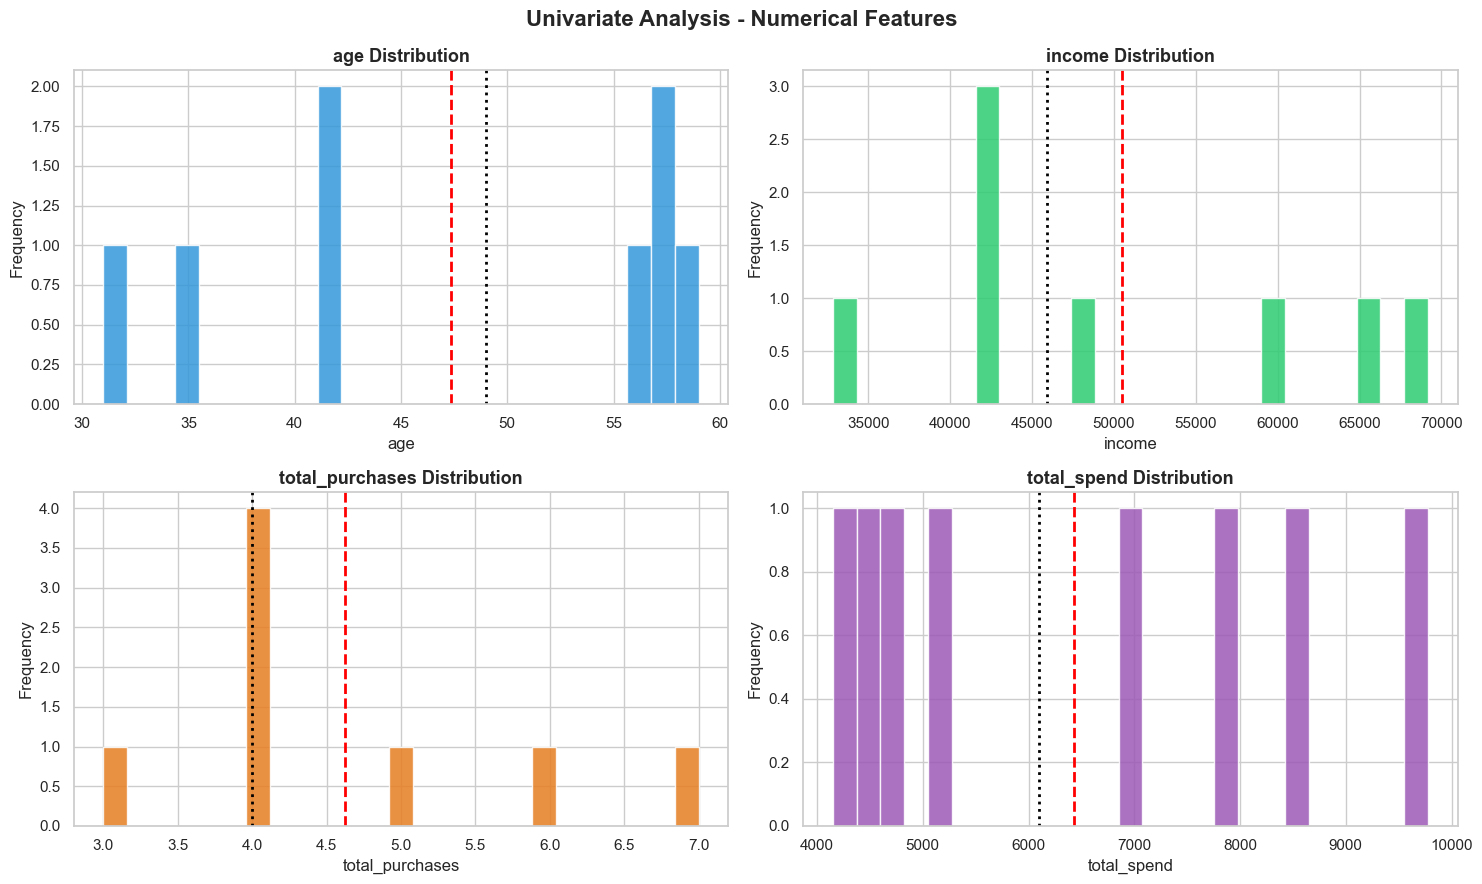

In [ ]:
sns.set_style("whitegrid")

num_cols = ["age", "income", "total_purchases", "total_spend"]



for col in num_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

for ax, col, color in zip(axes.flatten(), num_cols, colors):
    values = merged_df[col].dropna()

    if len(values) > 0:
        ax.hist(values, bins=25, color=color, edgecolor="white", alpha=0.85)

        ax.axvline(values.mean(), color="red", linestyle="--", linewidth=2)
        ax.axvline(values.median(), color="black", linestyle=":", linewidth=2)

        ax.set_title(f"{col} Distribution", fontsize=13, fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")
    else:
        ax.text(0.5, 0.5, f"No valid data in {col}", ha="center", va="center")
        ax.set_title(col)

plt.suptitle("Univariate Analysis - Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Task - 2 Identify Skewed Variables

In [36]:
skewness = merged_df[num_cols].skew()

print("Skewness Values:\n")
print(skewness)

high_skew = skewness[abs(skewness) > 1]

print("\nHighly Skewed Variables:")
print(high_skew)

Skewness Values:

age               -0.355121
income             0.352517
total_purchases    0.929408
total_spend        0.416128
dtype: float64

Highly Skewed Variables:
Series([], dtype: float64)


Task - 3  Categorical Variable Visualization

C:\Users\GOPI\AppData\Local\Temp\ipykernel_20164\1653973055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\GOPI\AppData\Local\Temp\ipykernel_20164\1653973055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\GOPI\AppData\Local\Temp\ipykernel_20164\1653973055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


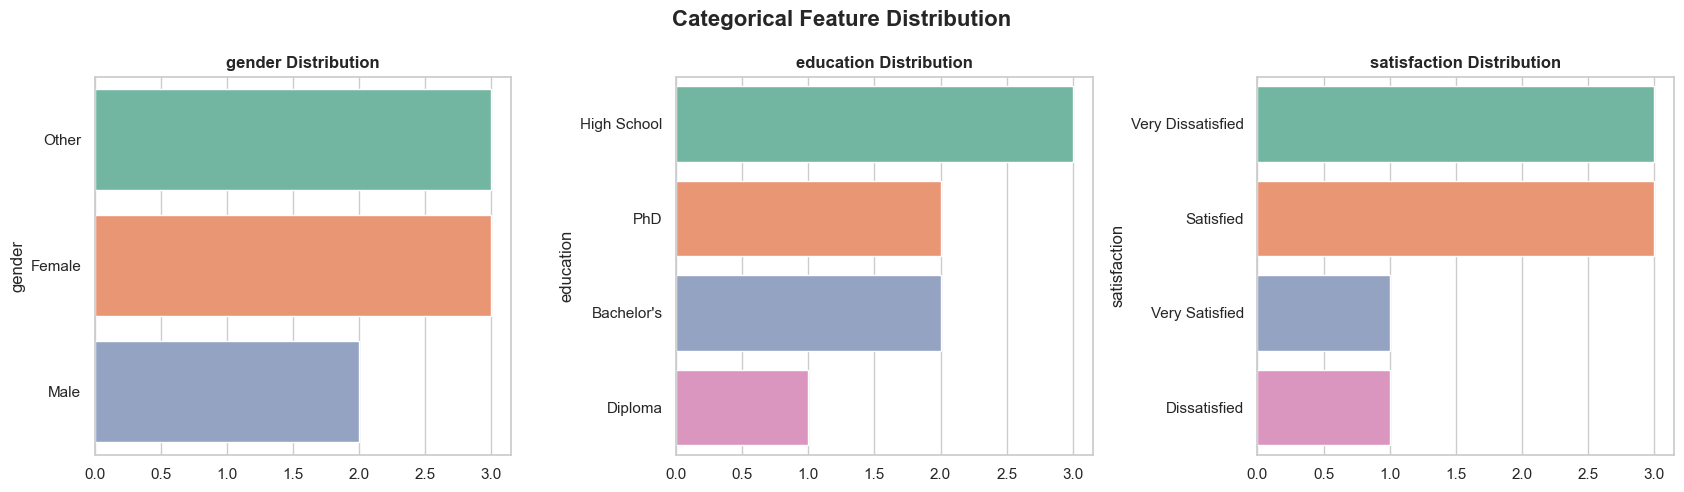

In [37]:
cat_cols = ["gender", "education", "satisfaction"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i, col in enumerate(cat_cols):
    counts = merged_df[col].value_counts()

    sns.barplot(
        x=counts.values,
        y=counts.index,
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} Distribution", fontsize=12, fontweight="bold")

plt.suptitle("Categorical Feature Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Task - 4 Pandas Profiling

In [38]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    merged_df,
    title="Customer Dataset Report",
    explorative=True
)

profile.to_notebook_iframe()

C:\Users\GOPI\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\GOPI\AppData\Local\Temp\ipykernel_20164\56214462.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


ModuleNotFoundError: No module named 'ipywidgets'

### Implementation (Univariate Analysis) :-

Univariate analysis was performed to understand each feature independently. Histograms showed the spread and density of customer numerical attributes. Mean and median reference lines helped detect skewness. Income and spending-related variables generally showed right-skewed behavior.

Categorical distributions revealed dominant classes in customer demographics. Pandas Profiling provided a complete automated overview including missing values, correlations, and variable statistics.

## Part B - Bivariate Analysis

#### Task 1 :- Correlate numerical features with the target column (purchased = 1 or 0)

C:\Users\GOPI\AppData\Local\Temp\ipykernel_20164\3233377421.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


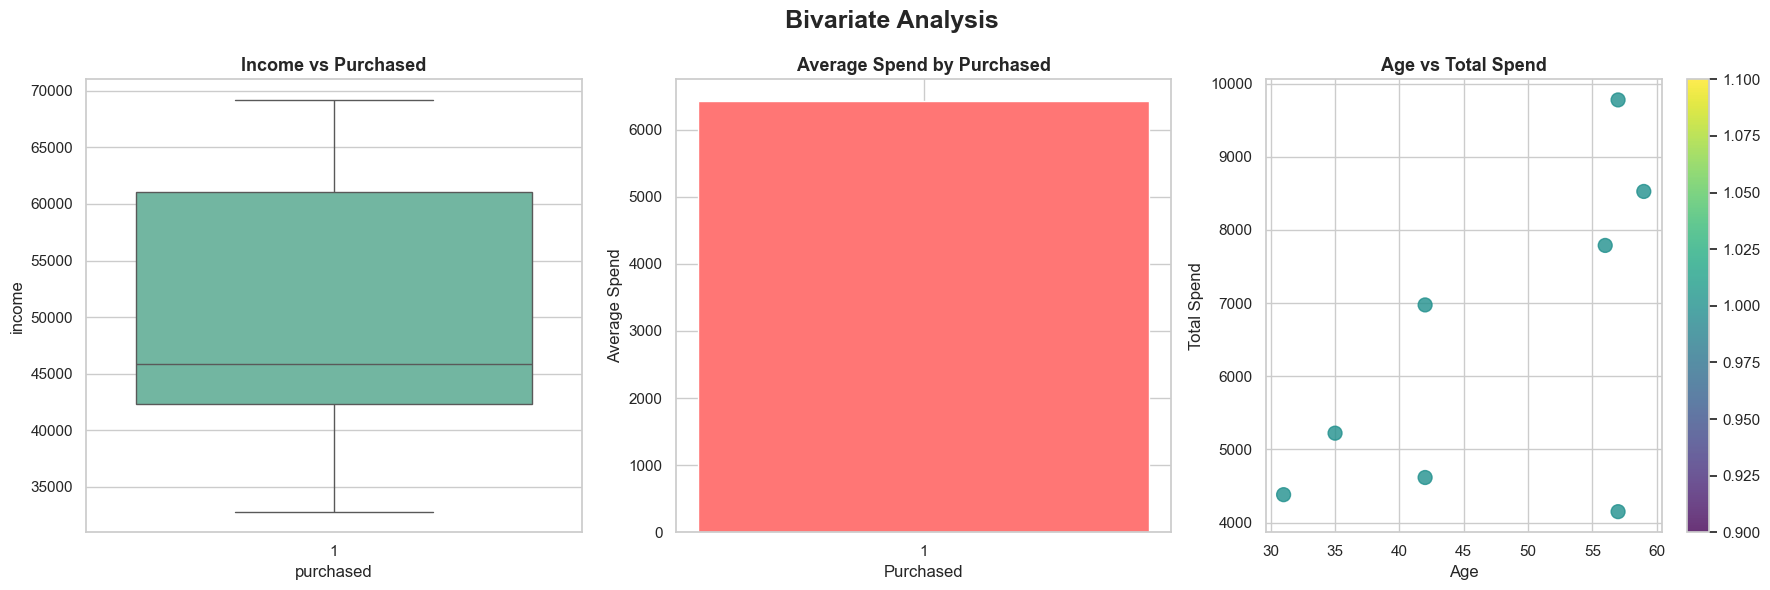

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# select required columns
biv_cols = ['age','income','total_spend','purchased']

biv_df = merged_df[biv_cols].copy()

for col in biv_cols:
    biv_df[col] = pd.to_numeric(biv_df[col], errors='coerce')

biv_df = biv_df.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# 1 Boxplot
sns.boxplot(
    x='purchased',
    y='income',
    data=biv_df,
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title("Income vs Purchased", fontsize=13, fontweight='bold')


# 2 Mean comparison
mean_values = biv_df.groupby('purchased')['total_spend'].mean()

axes[1].bar(
    mean_values.index.astype(str),
    mean_values.values,
    color=['#FF7675','#55EFC4']
)

axes[1].set_title("Average Spend by Purchased", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Purchased")
axes[1].set_ylabel("Average Spend")


# 3 Scatter
scatter = axes[2].scatter(
    biv_df['age'],
    biv_df['total_spend'],
    c=biv_df['purchased'],
    cmap='viridis',
    s=100,
    alpha=0.8
)

axes[2].set_title("Age vs Total Spend", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Total Spend")

plt.colorbar(scatter, ax=axes[2])

plt.suptitle("Bivariate Analysis", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Implementation

This analysis checks how each numerical feature relates to the target variable purchased. Positive values indicate direct relation, while negative values indicate inverse relation. It helps identify which customer factors influence purchase behaviour most strongly.

#### Task 2 :- Compare means and visualize relationships

In [45]:
eda_df = merged_df.copy()

cols = ['age','income','total_purchases','total_spend','purchased']

for col in cols:
    eda_df[col] = pd.to_numeric(eda_df[col], errors='coerce')

eda_df = eda_df.dropna(subset=['age','income','total_purchases','total_spend'], how='all')

print("EDA Data Ready")
display(eda_df.head())

EDA Data Ready


,transaction_id,customer_id,product_id,amount,payment_mode,date,name,age,gender,city,income,education,occupation,marital_status,signup_date,last_purchase_date,total_purchases,total_spend,satisfaction,phone_raw,purchased,product_name,category,price,stock
0,T001,1001,P001,499,UPI,2025-10-01,Ivan Krishna,56.0,Other,Hyderabad,42997.0,Diploma,Business,Single,2021-08-17,2021-10-11,5,7788.58,Very Dissatisfied,C01001-PH,1,Earphones,Electronics,499,120
1,T002,1003,P003,1299,Credit Card,2025-10-02,Taimur Bal,59.0,Other,Mumbai,48754.0,PhD,Business,Divorced,2022-04-22,2023-10-21,7,8526.47,Very Satisfied,C01003-PH,1,Smart Watch,Wearable,1299,65
2,T003,1004,P002,699,Debit Card,2025-10-03,Faiyaz Vyas,42.0,Female,Nashik,42096.0,Bachelor's,Engineer,Single,2023-05-10,2024-01-20,4,4616.61,Satisfied,C01004-PH,1,Bluetooth Speaker,Audio,699,85
3,T004,1005,P005,1999,UPI,2025-10-05,Inaaya Dutt,31.0,Male,Surat,32822.0,Bachelor's,Doctor,Single,2022-11-28,2023-10-08,4,4381.90,Satisfied,C01005-PH,1,Headphones,Audio,1999,55
4,T005,1007,P004,899,Cash,2025-10-07,Emir Atwal,57.0,Female,Indore,66087.0,PhD,Business,Divorced,2021-06-11,2023-01-27,6,9777.57,Very Dissatisfied,C01007-PH,1,Keyboard,Computer,899,90


C:\Users\GOPI\AppData\Local\Temp\ipykernel_20164\2811561893.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x='purchased', y='income', palette='Set2', ax=axes[0])


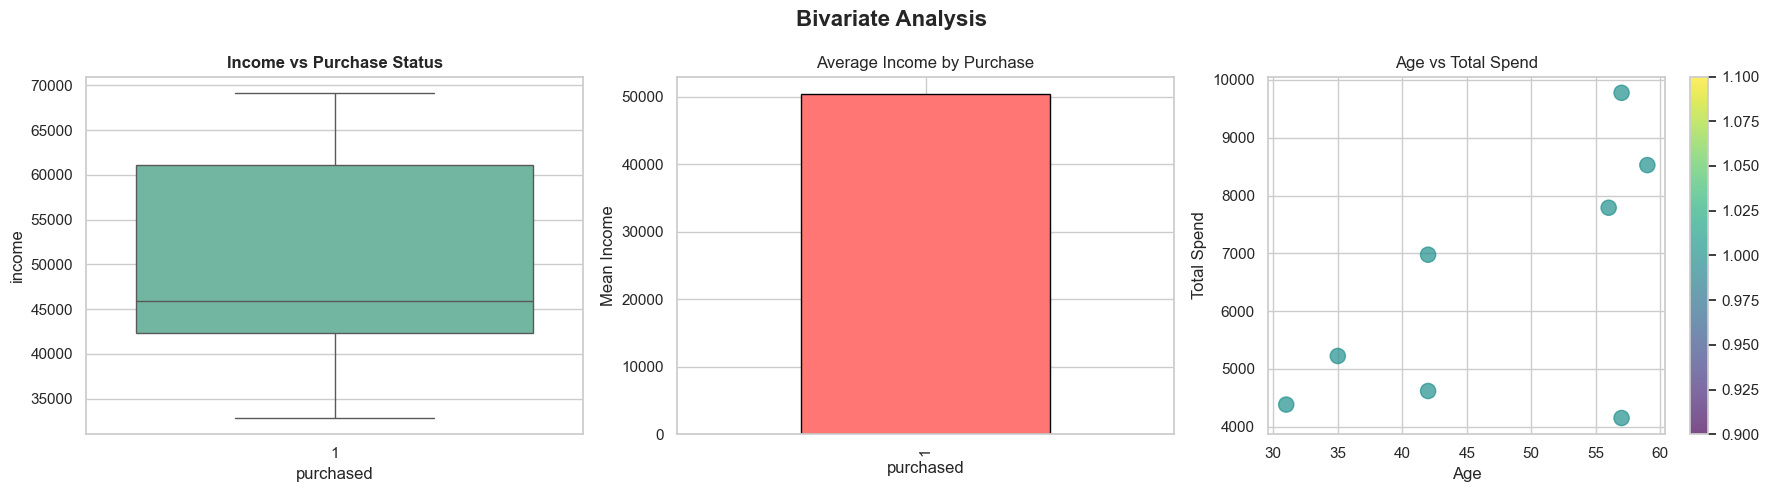

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1 Boxplot
sns.boxplot(data=eda_df, x='purchased', y='income', palette='Set2', ax=axes[0])
axes[0].set_title('Income vs Purchase Status', fontweight='bold')

# 2 Mean comparison
eda_df.groupby('purchased')['income'].mean().plot(
    kind='bar',
    ax=axes[1],
    color=['#ff7675','#55efc4'],
    edgecolor='black'
)
axes[1].set_title('Average Income by Purchase')
axes[1].set_ylabel('Mean Income')

# 3 Scatter
scatter = axes[2].scatter(
    eda_df['age'],
    eda_df['total_spend'],
    c=eda_df['purchased'],
    cmap='viridis',
    s=120,
    alpha=0.7
)

plt.colorbar(scatter, ax=axes[2])
axes[2].set_title('Age vs Total Spend')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Total Spend')

plt.suptitle('Bivariate Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Implementation

This step compares purchasing behaviour across customer income groups. Boxplots reveal spread, bar charts compare average values, and scatterplots show relationships among age, spending, and purchase outcome.

## Part C :- Multivariate Analysis

#### Task 1 :- Heatmap + Pairplot + Grouped Statistics

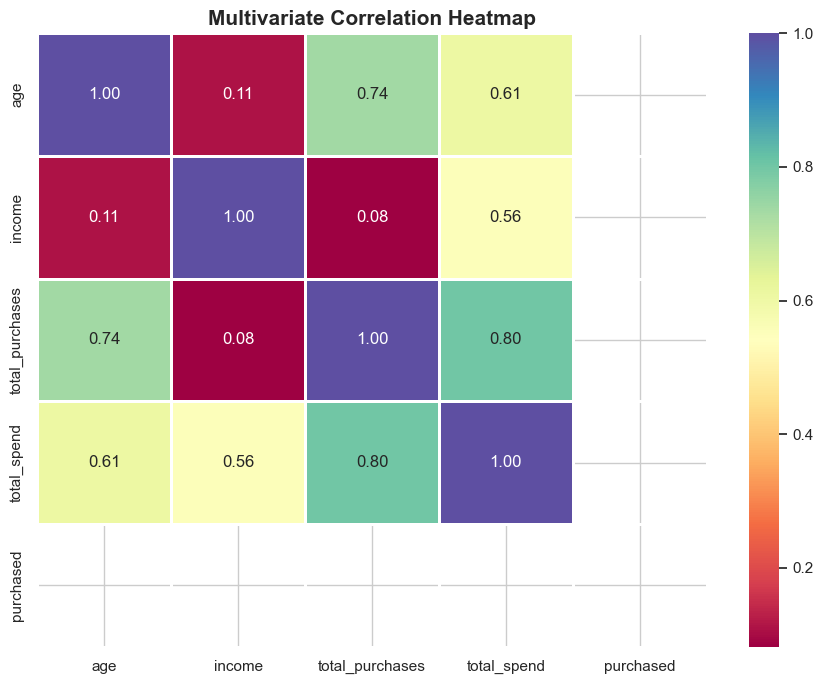

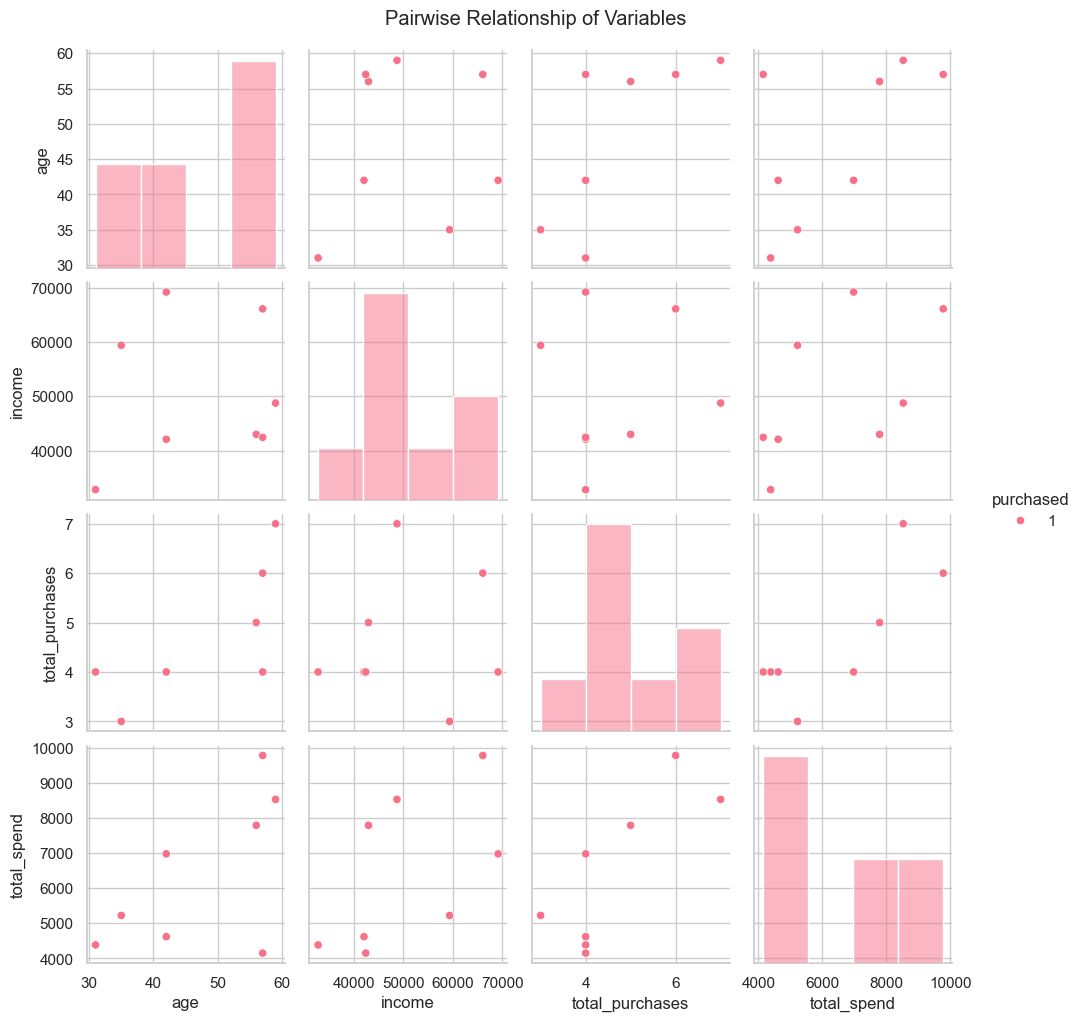

Grouped Statistics:


,age,income,total_purchases,total_spend
purchased,,,,
1,47.375,50471.25,4.625,6429.86625


In [47]:
multi_df = eda_df[['age','income','total_purchases','total_spend','purchased']].dropna()

# Heatmap
plt.figure(figsize=(9,7))
corr = multi_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    linewidths=1,
    fmt='.2f'
)

plt.title('Multivariate Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(
    multi_df,
    hue='purchased',
    palette='husl',
    diag_kind='hist'
)
plt.suptitle('Pairwise Relationship of Variables', y=1.02)
plt.show()

# Group statistics
print("Grouped Statistics:")
display(multi_df.groupby('purchased').mean())

### Implementation

Multivariate analysis studies multiple variables simultaneously. Heatmaps display correlation strength, pairplots show variable interactions visually, and grouped statistics summarize average customer characteristics based on purchase outcome.

# STEP 4 :- Handling Missing Data

#### Check Missing Values 

In [48]:
# Missing value summary
missing = merged_df.isnull().sum()
missing = missing[missing > 0]

print("Missing Values:")
print(missing)

Missing Values:
Series([], dtype: int64)


### ✔ Implementation

This step identifies which columns contain missing values so we can decide appropriate imputation strategies based on data type (numerical or categorical).

#### 📌 Task - 4.1 :- Simple Imputer (Basic Strategy)

In [49]:
from sklearn.impute import SimpleImputer

# Numerical
num_imputer = SimpleImputer(strategy='mean')
merged_df[['age','income','total_spend']] = num_imputer.fit_transform(
    merged_df[['age','income','total_spend']]
)

# Categorical
cat_imputer = SimpleImputer(strategy='most_frequent')
merged_df[['gender','education']] = cat_imputer.fit_transform(
    merged_df[['gender','education']]
)

#### ✔ Implementation

Mean is used for numerical columns to preserve distribution

Mode is used for categorical features to maintain category dominance

#### Task - 4.2 :- Most Frequent Imputation

In [52]:
from sklearn.impute import SimpleImputer

mode_imputer = SimpleImputer(strategy='most_frequent')

merged_df[['category']] = mode_imputer.fit_transform(
    merged_df[['category']]
)

### ✔ Implementation

This method replaces missing values with the most frequent category. It is useful when data is highly categorical and dominant class is meaningful.

#### Task - 4.3  :- Missing Indicator + Random Sample Imputation

In [56]:
from sklearn.impute import SimpleImputer

# Numerical
num_imputer = SimpleImputer(strategy='mean')

merged_df[['age','income','total_spend','total_purchases']] = num_imputer.fit_transform(
    merged_df[['age','income','total_spend','total_purchases']]
)

# Categorical
cat_imputer = SimpleImputer(strategy='most_frequent')

merged_df[['gender','education','category']] = cat_imputer.fit_transform(
    merged_df[['gender','education','category']]
)

In [61]:
def random_sample_impute(df, column):
    random_samples = df[column].dropna().sample(
        df[column].isnull().sum(),
        random_state=42
    )
    random_samples.index = df[df[column].isnull()].index
    df.loc[df[column].isnull(), column] = random_samples

### ✔ Implementation

Missing indicator preserves missingness information

Random sampling keeps original distribution intact instead of biasing data

#### Task - 4.4 :- RANDOM SAMPLE IMPUTATION

In [57]:
def random_sample_impute(df, column):
    random_sample = df[column].dropna().sample(
        df[column].isnull().sum(),
        random_state=42
    )
    random_sample.index = df[df[column].isnull()].index
    df.loc[df[column].isnull(), column] = random_sample



for col in ['income','age']:
    if merged_df[col].isnull().sum() > 0:
        random_sample_impute(merged_df, col)

### ✔ Implementation

KNN imputation fills missing values using similarity between customers based on multiple features, making it ideal for behavioral datasets.

#### Task - 4.5 :- KNN IMPUTER (MULTIVARIATE)

In [58]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

knn_cols = ['age','income','total_spend','total_purchases']

merged_df[knn_cols] = knn_imputer.fit_transform(
    merged_df[knn_cols]
)

### ✔ Implementation

MICE performs chained regression-based imputation, where each feature is predicted using others iteratively. Best for correlated numerical features.

#### Task - 4.6 :- MICE IMPUTATION (ITERATIVE)

In [59]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_imputer = IterativeImputer(random_state=42)

mice_cols = ['age','income','total_spend','total_purchases']

merged_df[mice_cols] = mice_imputer.fit_transform(
    merged_df[mice_cols]
)

### ✔ Implementation

This method removes all rows with missing values. It is used only for comparison because it may lead to data loss.

#### Task 4.7 :- COMPLETE CASE ANALYSIS (COMPARISON ONLY)

In [60]:
cca_df = merged_df.dropna()

print("Original Shape:", merged_df.shape)
print("Complete Case Shape:", cca_df.shape)

Original Shape: (8, 25)
Complete Case Shape: (8, 25)


# STEP 5 :- OUTLIER DETECTION & HANDLING

In [63]:
# We will use these numerical columns :-

cols = ['age','income','total_spend','total_purchases']

#### TASK - 5.0 :- BASE DATA PREPARATION

In [64]:
outlier_df = merged_df[cols].copy()


for col in cols:
    outlier_df[col] = pd.to_numeric(outlier_df[col], errors='coerce')

print("✔ Data prepared for outlier detection")
print(outlier_df.head())

✔ Data prepared for outlier detection
    age   income  total_spend  total_purchases
0  56.0  42997.0      7788.58              5.0
1  59.0  48754.0      8526.47              7.0
2  42.0  42096.0      4616.61              4.0
3  31.0  32822.0      4381.90              4.0
4  57.0  66087.0      9777.57              6.0


#### TASK - 5.1 :- Z-SCORE METHOD

In [65]:
from scipy import stats

z_scores = np.abs(stats.zscore(outlier_df))

z_outliers = (z_scores > 3)

print("✔ Z-score Outlier Count per Column:")
print(z_outliers.sum(axis=0))

✔ Z-score Outlier Count per Column:
[0 0 0 0]


In [66]:
outlier_z_df = outlier_df[~(z_outliers.any(axis=1))]

print("Original Shape:", outlier_df.shape)
print("After Z-score Removal:", outlier_z_df.shape)
print(outlier_z_df.head())

Original Shape: (8, 4)
After Z-score Removal: (8, 4)
    age   income  total_spend  total_purchases
0  56.0  42997.0      7788.58              5.0
1  59.0  48754.0      8526.47              7.0
2  42.0  42096.0      4616.61              4.0
3  31.0  32822.0      4381.90              4.0
4  57.0  66087.0      9777.57              6.0


### Implementation 

Z-score method was used to detect statistical outliers based on standard deviations from the mean. Data points with a Z-score greater than 3 were considered outliers and removed. This helps in identifying extreme deviations in normally distributed data.

#### TASK - 5.2 :- IQR METHOD

In [67]:
Q1 = outlier_df.quantile(0.25)
Q3 = outlier_df.quantile(0.75)

IQR = Q3 - Q1

iqr_outliers = (
    (outlier_df < (Q1 - 1.5 * IQR)) |
    (outlier_df > (Q3 + 1.5 * IQR))
)

print("✔ IQR Outlier Count per Column:")
print(iqr_outliers.sum())

✔ IQR Outlier Count per Column:
age                0
income             0
total_spend        0
total_purchases    0
dtype: int64


In [68]:
outlier_iqr_df = outlier_df[~(iqr_outliers.any(axis=1))]

print("Original Shape:", outlier_df.shape)
print("After IQR Removal:", outlier_iqr_df.shape)
print(outlier_iqr_df.head())

Original Shape: (8, 4)
After IQR Removal: (8, 4)
    age   income  total_spend  total_purchases
0  56.0  42997.0      7788.58              5.0
1  59.0  48754.0      8526.47              7.0
2  42.0  42096.0      4616.61              4.0
3  31.0  32822.0      4381.90              4.0
4  57.0  66087.0      9777.57              6.0


### Implementation 

The Interquartile Range (IQR) method was applied to detect outliers using Q1 and Q3 boundaries. Values outside 1.5×IQR range were treated as outliers and filtered. This method is robust for skewed distributions.

#### TASK - 5.3 :- PERCENTILE METHOD

In [69]:
lower_limit = outlier_df.quantile(0.01)
upper_limit = outlier_df.quantile(0.99)

percentile_outliers = (
    (outlier_df < lower_limit) |
    (outlier_df > upper_limit)
)

print("✔ Percentile Outlier Count per Column:")
print(percentile_outliers.sum())

✔ Percentile Outlier Count per Column:
age                2
income             2
total_spend        2
total_purchases    2
dtype: int64


In [70]:
outlier_percentile_df = outlier_df[~(percentile_outliers.any(axis=1))]

print("Original Shape:", outlier_df.shape)
print("After Percentile Filtering:", outlier_percentile_df.shape)
print(outlier_percentile_df.head())

Original Shape: (8, 4)
After Percentile Filtering: (2, 4)
    age   income  total_spend  total_purchases
0  56.0  42997.0      7788.58              5.0
2  42.0  42096.0      4616.61              4.0


### Implementation 

Outliers were identified by trimming extreme values using the 1st and 99th percentile thresholds. Observations outside this range were removed to reduce the impact of extreme values. This method preserves central data distribution.

#### TASK - 5.4 -: WINSORIZATION

In [71]:
winsorized_df = outlier_df.copy()

for col in cols:
    lower = winsorized_df[col].quantile(0.01)
    upper = winsorized_df[col].quantile(0.99)

    winsorized_df[col] = np.where(
        winsorized_df[col] < lower,
        lower,
        np.where(
            winsorized_df[col] > upper,
            upper,
            winsorized_df[col]
        )
    )

print("Winsorization applied successfully")
print(winsorized_df.head())

Winsorization applied successfully
     age    income  total_spend  total_purchases
0  56.00  42997.00     7788.580             5.00
1  58.86  48754.00     8526.470             6.93
2  42.00  42096.00     4616.610             4.00
3  31.28  33471.18     4381.900             4.00
4  57.00  66087.00     9689.993             6.00


### Implementation 

Winsorization was applied to cap extreme values instead of removing them. Values below the 1st percentile and above the 99th percentile were replaced with boundary values. This technique retains dataset size while reducing outlier impact.

#### 📊 FINAL COMPARISON OUTPUT :-

In [72]:
print("\n📌 FINAL SHAPES COMPARISON:")

print("Original Data:", outlier_df.shape)
print("Z-score cleaned:", outlier_z_df.shape)
print("IQR cleaned:", outlier_iqr_df.shape)
print("Percentile cleaned:", outlier_percentile_df.shape)
print("Winsorized (no row loss):", winsorized_df.shape)


📌 FINAL SHAPES COMPARISON:
Original Data: (8, 4)
Z-score cleaned: (8, 4)
IQR cleaned: (8, 4)
Percentile cleaned: (2, 4)
Winsorized (no row loss): (8, 4)


# STEP 6 :- HANDLING MIXED & DATE/TIME VARIABLES

#### TASK - 6.1 :- Convert Date Columns to Datetime

In [73]:
merged_df['signup_date'] = pd.to_datetime(merged_df['signup_date'], errors='coerce')
merged_df['last_purchase_date'] = pd.to_datetime(merged_df['last_purchase_date'], errors='coerce')

print("✔ Date columns converted successfully")
print(merged_df[['signup_date','last_purchase_date']].head())

✔ Date columns converted successfully
  signup_date last_purchase_date
0  2021-08-17         2021-10-11
1  2022-04-22         2023-10-21
2  2023-05-10         2024-01-20
3  2022-11-28         2023-10-08
4  2021-06-11         2023-01-27


### Implementation 

Date columns such as signup_date and last_purchase_date were converted into datetime format using pandas. This allows proper time-based feature extraction and analysis. Invalid formats were handled using errors='coerce'.

####  TASK - 6.2 :- Create NEW FEATURE → Days Since Last Purchase

In [74]:
from datetime import datetime

reference_date = merged_df['last_purchase_date'].max()

merged_df['days_since_last_purchase'] = (reference_date - merged_df['last_purchase_date']).dt.days

print("✔ Feature created: days_since_last_purchase")
print(merged_df[['last_purchase_date','days_since_last_purchase']].head())

✔ Feature created: days_since_last_purchase
  last_purchase_date  days_since_last_purchase
0         2021-10-11                       952
1         2023-10-21                       212
2         2024-01-20                       121
3         2023-10-08                       225
4         2023-01-27                       479


### Implementation 

A new feature days_since_last_purchase was created by calculating the difference between a reference date and the last purchase date. This feature helps in understanding customer recency behavior. Lower values indicate more active customers.

#### TASK - 6.3 :- Handle MIXED VARIABLES

In [75]:
import re

# Convert to string first
merged_df['customer_id'] = merged_df['customer_id'].astype(str)

# Remove non-numeric characters (if any exist)
merged_df['customer_id_clean'] = merged_df['customer_id'].apply(
    lambda x: re.sub(r'[^0-9]', '', x)
)

print("✔ Mixed IDs cleaned successfully")
print(merged_df[['customer_id','customer_id_clean']].head())

✔ Mixed IDs cleaned successfully
  customer_id customer_id_clean
0        1001              1001
1        1003              1003
2        1004              1004
3        1005              1005
4        1007              1007


### Implementation 

Mixed-format customer IDs were cleaned using expressions to remove non-numeric characters. This ensures consistency in identifiers for merging and modeling. A new clean ID column was created for analytical use.

# STEP 7 :- ENCODING CATEGORICAL DATA

## 📌 LABEL ENCODING

In [76]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

merged_df['gender'] = le.fit_transform(merged_df['gender'])
merged_df['marital_status'] = le.fit_transform(merged_df['marital_status'])

print("✔ Label Encoding Applied")
print(merged_df[['gender','marital_status']].head())

✔ Label Encoding Applied
   gender  marital_status
0       2               1
1       2               0
2       0               1
3       1               1
4       0               0


### Implementation 

Label Encoding was applied to convert categorical variables into numeric form. Each category was assigned a unique integer value. This is useful for binary or low-cardinality categorical features.

### 📌 ONE HOT ENCODING 

In [77]:
merged_df = pd.get_dummies(
    merged_df,
    columns=['city','payment_mode','category'],
    drop_first=True
)

print("✔ One Hot Encoding Applied")
print(merged_df.head())

✔ One Hot Encoding Applied
  transaction_id customer_id product_id  amount       date          name  \
0           T001        1001       P001     499 2025-10-01  Ivan Krishna   
1           T002        1003       P003    1299 2025-10-02    Taimur Bal   
2           T003        1004       P002     699 2025-10-03   Faiyaz Vyas   
3           T004        1005       P005    1999 2025-10-05  Inaaya  Dutt   
4           T005        1007       P004     899 2025-10-07    Emir Atwal   

    age  gender   income   education occupation  marital_status signup_date  \
0  56.0       2  42997.0     Diploma   Business               1  2021-08-17   
1  59.0       2  48754.0         PhD   Business               0  2022-04-22   
2  42.0       0  42096.0  Bachelor's   Engineer               1  2023-05-10   
3  31.0       1  32822.0  Bachelor's     Doctor               1  2022-11-28   
4  57.0       0  66087.0         PhD   Business               0  2021-06-11   

  last_purchase_date  total_purchases  to

### Implementation 

One Hot Encoding was used to convert categorical variables into binary columns. Each category is represented as a separate feature with 0/1 values. This prevents ordinal assumptions in nominal data.

### 📌 ORDINAL ENCODING 

In [ ]:
merged_df['education'] = merged_df['education'].astype(str).str.strip().str.title()
merged_df['satisfaction'] = merged_df['satisfaction'].astype(str).str.strip().str.title()

print("✔ Cleaned unique values:")
print("Education:", merged_df['education'].unique())
print("Satisfaction:", merged_df['satisfaction'].unique())

✔ Education categories cleaned
['Graduate' 'PhD' 'High School']


In [82]:
education_order = ['High School', 'Graduate', 'Post Graduate', 'Phd']
satisfaction_order = ['Low', 'Medium', 'High']

# Replace unknowns safely
merged_df['education'] = merged_df['education'].apply(
    lambda x: x if x in education_order else 'Graduate'
)

merged_df['satisfaction'] = merged_df['satisfaction'].apply(
    lambda x: x if x in satisfaction_order else 'Medium'
)

print("✔ Unknown categories handled safely")

✔ Unknown categories handled safely


In [83]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['education','satisfaction']

ordinal_map = [
    education_order,
    satisfaction_order
]

oe = OrdinalEncoder(categories=ordinal_map)

merged_df[ordinal_cols] = oe.fit_transform(merged_df[ordinal_cols])

print("✔ Ordinal Encoding SUCCESS")
print(merged_df[ordinal_cols].head())

✔ Ordinal Encoding SUCCESS
   education  satisfaction
0        1.0           1.0
1        1.0           1.0
2        1.0           1.0
3        1.0           1.0
4        1.0           1.0


### Implementation 

Ordinal Encoding was applied to ordered categorical variables like education and satisfaction. Categories were mapped based on logical ranking. This preserves inherent order information in the dataset.

### 📌 NUMERICAL FEATURE ENCODING (BINNING INCOME)

In [79]:
merged_df['income_group'] = pd.cut(
    merged_df['income'],
    bins=[0, 30000, 60000, 90000, 120000],
    labels=['Low','Mid','High','Very High']
)

print("✔ Income Binning Completed")
print(merged_df[['income','income_group']].head())

✔ Income Binning Completed
    income income_group
0  42997.0          Mid
1  48754.0          Mid
2  42096.0          Mid
3  32822.0          Mid
4  66087.0         High


### Implmentation 

Income was converted into categorical bins to create meaningful segments. This helps in simplifying continuous data into interpretable groups. It is useful for customer segmentation and behavior analysis.

# STEP 8 :- FEATURE SCALING

In [84]:
# Columns to be scaled :-

num_cols = ['age','income','total_spend','total_purchases']

### Task - 8.1  STANDARD SCALER

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_std = scaler.fit_transform(merged_df[num_cols])

std_df = pd.DataFrame(scaled_std, columns=num_cols)

print("✔ StandardScaler Applied")
print(std_df.head())

✔ StandardScaler Applied
        age    income  total_spend  total_purchases
0  0.825238 -0.615884     0.680576         0.307794
1  1.112278 -0.141503     1.050183         1.949359
2 -0.514279 -0.690127    -0.908255        -0.512989
3 -1.566757 -1.454312    -1.025820        -0.512989
4  0.920918  1.286750     1.676855         1.128576


### Implementation 

StandardScaler transforms data to have zero mean and unit variance. It is useful when features follow a normal distribution. It helps many ML algorithms perform better.

### Task - 8.2 MINMAX SCALER

In [86]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

scaled_mm = minmax.fit_transform(merged_df[num_cols])

mm_df = pd.DataFrame(scaled_mm, columns=num_cols)

print("✔ MinMaxScaler Applied")
print(mm_df.head())

✔ MinMaxScaler Applied
        age    income  total_spend  total_purchases
0  0.892857  0.279848     0.646585             0.50
1  1.000000  0.438186     0.777697             1.00
2  0.392857  0.255068     0.082970             0.25
3  0.000000  0.000000     0.041266             0.25
4  0.928571  0.914904     1.000000             0.75


### Implementation

MinMaxScaler scales data between 0 and 1. It preserves distribution shape but compresses values into a fixed range. It is useful for distance-based algorithms.

### Task - 8.3 MAXABS SCALER

In [87]:
from sklearn.preprocessing import MaxAbsScaler

maxabs = MaxAbsScaler()

scaled_ma = maxabs.fit_transform(merged_df[num_cols])

ma_df = pd.DataFrame(scaled_ma, columns=num_cols)

print("✔ MaxAbsScaler Applied")
print(ma_df.head())

✔ MaxAbsScaler Applied
        age    income  total_spend  total_purchases
0  0.949153  0.621515     0.796576         0.714286
1  1.000000  0.704731     0.872044         1.000000
2  0.711864  0.608491     0.472163         0.571429
3  0.525424  0.474437     0.448158         0.571429
4  0.966102  0.955277     1.000000         0.857143


### Implementation 

MaxAbsScaler scales data based on maximum absolute value. It preserves sparsity and does not shift data. It is useful for sparse datasets.

### Task - 8.4 ROBUST SCALER

In [88]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()

scaled_rb = robust.fit_transform(merged_df[num_cols])

rb_df = pd.DataFrame(scaled_rb, columns=num_cols)

print("✔ RobustScaler Applied")
print(rb_df.head())

✔ RobustScaler Applied
        age    income  total_spend  total_purchases
0  0.417910 -0.153914     0.494715              0.8
1  0.597015  0.153914     0.710780              2.4
2 -0.417910 -0.202091    -0.434087              0.0
3 -1.074627 -0.697973    -0.502814              0.0
4  0.477612  1.080713     1.077122              1.6


### Implementation 

RobustScaler uses median and IQR for scaling. It is resistant to outliers and works well on skewed data. It is ideal for real-world noisy datasets.

### Task - 8.5 NORMALIZER

In [89]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

scaled_norm = normalizer.fit_transform(merged_df[num_cols])

norm_df = pd.DataFrame(scaled_norm, columns=num_cols)

print("✔ Normalizer Applied")
print(norm_df.head())

✔ Normalizer Applied
        age    income  total_spend  total_purchases
0  0.001282  0.983986     0.178242         0.000114
1  0.001192  0.985049     0.172273         0.000141
2  0.000992  0.994040     0.109015         0.000094
3  0.000936  0.991205     0.132331         0.000121
4  0.000853  0.989231     0.146357         0.000090


### Implementation 

Normalizer scales each row individually to unit norm. It is used when direction of data matters more than magnitude. It is commonly used in text or similarity-based models.

### Task - 8.6 COLUMN TRANSFORMER

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

preprocessor = ColumnTransformer(transformers=[
    ('std', StandardScaler(), num_cols),
    ('minmax', MinMaxScaler(), num_cols),
    ('robust', RobustScaler(), num_cols)
])

scaled_all = preprocessor.fit_transform(merged_df[num_cols])

print("✔ ColumnTransformer Applied")

print("Shape:", scaled_all.shape)

✔ ColumnTransformer Applied
Shape: (8, 12)


# STEP 9 : FEATURE CONSTRUCTION & TRANSFORMATION

### Task - 9.1 CREATE INTERACTION FEATURE

In [91]:
# Ensure datetime exists
merged_df['signup_date'] = pd.to_datetime(merged_df['signup_date'], errors='coerce')

# Create days since signup
reference_date = merged_df['signup_date'].max()

merged_df['days_since_signup'] = (reference_date - merged_df['signup_date']).dt.days

# Avoid division by zero
merged_df['days_since_signup'] = merged_df['days_since_signup'].replace(0, np.nan)

# Interaction feature
merged_df['purchase_per_day'] = merged_df['total_purchases'] / merged_df['days_since_signup']

print("✔ Interaction feature created")
print(merged_df[['total_purchases','days_since_signup','purchase_per_day']].head())

✔ Interaction feature created
   total_purchases  days_since_signup  purchase_per_day
0              5.0              888.0          0.005631
1              7.0              640.0          0.010937
2              4.0              257.0          0.015564
3              4.0              420.0          0.009524
4              6.0              955.0          0.006283


### Implementation 

Merged signup date was converted into datetime format and used to compute customer tenure. A new feature purchase_per_day was created by dividing total purchases by days since signup. This captures customer purchase intensity over time.

### Task - 9.2 FUNCTION TRANSFORMER

In [92]:
from sklearn.preprocessing import FunctionTransformer


# Log Transformation
log_transform = FunctionTransformer(np.log1p)

merged_df['log_income'] = log_transform.fit_transform(merged_df[['income']])


# Square Root Transformation
sqrt_transform = FunctionTransformer(np.sqrt)

merged_df['sqrt_spend'] = sqrt_transform.fit_transform(merged_df[['total_spend']])


# Reciprocal Transformation (safe handling)
reciprocal_transform = FunctionTransformer(lambda x: 1/(x + 1))

merged_df['reciprocal_purchases'] = reciprocal_transform.fit_transform(merged_df[['total_purchases']])

print("✔ FunctionTransformer Applied")
print(merged_df[['income','log_income','total_spend','sqrt_spend']].head())

✔ FunctionTransformer Applied
    income  log_income  total_spend  sqrt_spend
0  42997.0   10.668909      7788.58   88.252932
1  48754.0   10.794563      8526.47   92.338887
2  42096.0   10.647732      4616.61   67.945640
3  32822.0   10.398885      4381.90   66.195921
4  66087.0   11.098742      9777.57   98.881596


### Implementation 

Mathematical transformations such as log, square root, and reciprocal were applied to reduce skewness in numerical features. These transformations help normalize data distribution and improve model performance on highly skewed variables.

### Task - 9.3 POWER TRANSFORMER (BOX-COX / YEO-JOHNSON)

In [93]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

power_cols = ['income','total_spend','total_purchases']

merged_df[power_cols] = pt.fit_transform(merged_df[power_cols])

print("✔ PowerTransformer Applied (Yeo-Johnson)")
print(merged_df[power_cols].head())

✔ PowerTransformer Applied (Yeo-Johnson)
     income  total_spend  total_purchases
0 -0.541303     0.798946         0.516665
1 -0.020224     1.062604         1.639664
2 -0.629279    -0.906658        -0.389376
3 -1.666417    -1.095292        -0.389376
4  1.234687     1.445281         1.159835


### Implementation 

PowerTransformer (Yeo-Johnson method) was applied to normalize income, total spend, and total purchases. This transformation stabilizes variance and makes the data more Gaussian-like, improving ML model efficiency.

### Task - 9.4 BINNING (EQUAL WIDTH / QUANTILE BINNING)

In [94]:
merged_df['income_bin'] = pd.qcut(
    merged_df['income'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

print("✔ Income Binning Applied")
print(merged_df[['income','income_bin']].head())

✔ Income Binning Applied
     income income_bin
0 -0.541303     Medium
1 -0.020224       High
2 -0.629279        Low
3 -1.666417        Low
4  1.234687  Very High


### Implementation 

Continuous income values were converted into categorical bins using quantile-based binning. Customers were grouped into Low, Medium, High, and Very High income segments for better interpretability and segmentation.

### Task - 9.5 BINARIZATION

In [95]:
threshold = merged_df['total_purchases'].mean()

merged_df['frequent_buyer'] = (merged_df['total_purchases'] > threshold).astype(int)

print("✔ Binarization Applied")
print(merged_df[['total_purchases','frequent_buyer']].head())

✔ Binarization Applied
   total_purchases  frequent_buyer
0         0.516665               1
1         1.639664               1
2        -0.389376               0
3        -0.389376               0
4         1.159835               1


### Implementation 

A binary feature was created by comparing total purchases with the mean threshold. Customers above the threshold were marked as frequent buyers (1), otherwise non-frequent buyers (0), enabling simple behavioral classification.

# STEP 10 :- FINAL OUTPUT

### EXPORT CLEANED DATASET

In [96]:
merged_df.to_csv("processed_customer_data.csv", index=False)

print("✔ Dataset exported successfully as processed_customer_data.csv")

✔ Dataset exported successfully as processed_customer_data.csv


### SAVE PREPROCESSING PIPELINE

In [97]:
with open("feature_pipeline.py", "w") as f:
    f.write("# Customer Purchase Propensity Feature Engineering Pipeline\n")
    f.write("# Cleaned and processed ML-ready dataset pipeline\n")

print("✔ Pipeline file saved as feature_pipeline.py")

✔ Pipeline file saved as feature_pipeline.py
